In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
!pip install xgboost

In [12]:
df = pd.read_csv("/content/train_u6lujuX_CVtuZ9i (1).csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()

Dataset Shape:
(614, 13)

Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
df.drop(columns=["Loan_ID"], inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [14]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [19]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]


numerical_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])


categorical_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


model_pipeline = Pipeline(steps=[
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [23]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}


results = []

best_model = None
best_f1 = 0
best_model_name = ""



TRAINING: Logistic Regression
Accuracy  : 0.8618
Precision : 0.8400
Recall    : 0.9882
F1 Score  : 0.9081


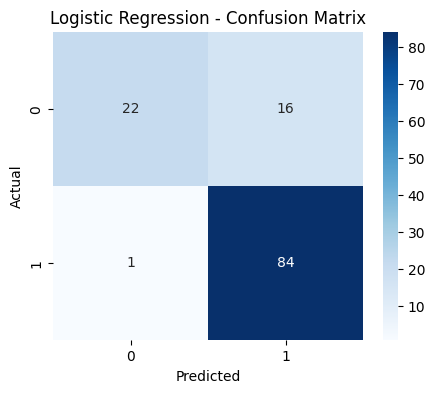


TRAINING: Random Forest
Accuracy  : 0.8293
Precision : 0.8333
Recall    : 0.9412
F1 Score  : 0.8840


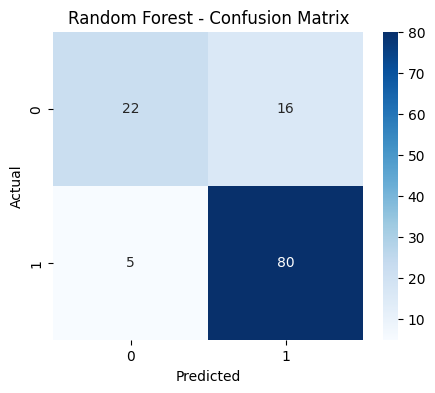


TRAINING: XGBoost
Accuracy  : 0.8211
Precision : 0.8462
Recall    : 0.9059
F1 Score  : 0.8750


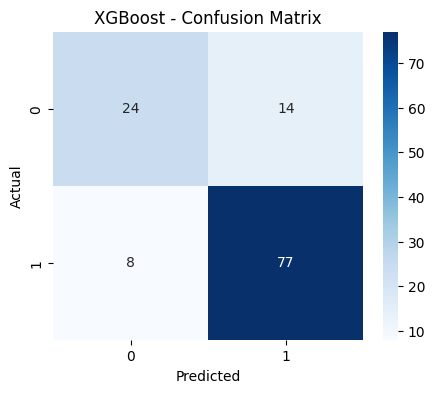

In [24]:
for model_name, model in models.items():

    print("\n====================================")
    print(f"TRAINING: {model_name}")
    print("====================================")

    # CREATE FULL PIPELINE
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # TRAIN
    pipeline.fit(X_train, y_train)

    # PREDICT
    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # METRICS
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # STORE RESULTS
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
    })

    # PRINT RESULTS
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # TRACK BEST MODEL
    if f1 > best_f1:

        best_f1 = f1
        best_model = pipeline
        best_model_name = model_name


In [25]:
print(best_model_name)

Logistic Regression


In [27]:
joblib.dump(
    best_model,
    "best_loan_risk_model.pkl"
)

['best_loan_risk_model.pkl']

In [28]:
for result in results:
    if result["Model"] == best_model_name:
        best_model_metrics = {
            "model_name": best_model_name,
            "accuracy": result["Accuracy"],
            "precision": result["Precision"],
            "recall": result["Recall"],
            "f1_score": result["F1 Score"]
        }
        break

import json

with open("model_metrics.json", "w") as json_file:
    json.dump(
        best_model_metrics,
        json_file,
        indent=4
    )

print("Best model metrics saved successfully.")

Best model metrics saved successfully.
